## 
Problem Statement

The objective of this project is to analyze XYZ Company's sales data from 2014 to 2018 to uncover key revenue and profit drivers across products, sales channels, and regions. The analysis aims to identify sales trends, seasonal patterns, and potential outliers that impact business performance. The insights generated from this analysis will help support data-driven decision-making for pricing strategies, promotional activities, and market expansion, ultimately contributing to improved business performance and sustainable growth.

In [58]:
# Importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
import os
print(os.getcwd())

C:\Users\itsra\OneDrive\Desktop\jupyter\regional sales analysis


In [3]:
os.listdir()

['.ipynb_checkpoints', 'data', 'final.csv', 'Regional sales analysis.ipynb']

In [4]:
sheets = pd.read_excel("data/Regional Sales Dataset.xlsx", sheet_name=None)

In [5]:
print(sheets.keys())

dict_keys(['Sales Orders', 'Customers', 'Regions', 'State Regions', 'Products', '2017 Budgets'])


In [6]:
# Assign dataframes to each sheet 
df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']
df_regions = sheets['Regions']

In [7]:
df_sales.head(6)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270
5,SO - 0010394,2014-01-01,138,Export,USD,NXH382,626,23,11,5219.3,57412.3,4332.019


In [8]:
df_sales.shape

(64104, 12)

In [9]:
print(f'df_sales shape:  {df_sales.shape}')

df_sales shape:  (64104, 12)


In [10]:
df_state_reg.head(6)

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West
5,CO,Colorado,West


In [11]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop = True)

df_state_reg.head(7)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West
5,CT,Connecticut,Northeast
6,DC,District of Columbia,South


In [12]:
df_products.head(6)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5
5,6,Product 6


In [13]:
df_customers.head(6)  

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd
5,6,Family Corp


In [14]:
  df_budgets.head(6) 

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542
5,Product 6,1672229.416


In [15]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [16]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [17]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [18]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [19]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

## Data cleaning and Wrangling 

In [20]:
#Merge with customers
df = df_sales.merge(
    df_customers, 
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)        

In [21]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [22]:
# merge with products 
df = df.merge(
    df_products, 
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)      

In [23]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [24]:
#merge with regions
df = df.merge(
    df_regions, 
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)        

In [25]:
df.head(4)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis


In [26]:
#merge with state regions
df = df.merge(
    df_state_reg[["State Code" , "Region"]], 
    how='left',
    left_on='state_code',
    right_on='State Code'
)    

In [27]:
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West


In [28]:
#merge with budgets
df = df.merge(
    df_budgets,
    how='left',
    on = 'Product Name'
)    

In [29]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [30]:
# Clean up redundant columns 
cols_to_drop = ['Customer Index' , 'Index' , 'id', 'State Code']
df = df.drop(columns = cols_to_drop,errors='ignore')
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [31]:
df.columns = df.columns.str.lower()
df.columns.values

<StringArray>
[              'ordernumber',                 'orderdate',
       'customer name index',                   'channel',
             'currency code',            'warehouse code',
     'delivery region index', 'product description index',
            'order quantity',                'unit price',
                'line total',           'total unit cost',
            'customer names',              'product name',
                      'name',                    'county',
                'state_code',                     'state',
                      'type',                  'latitude',
                 'longitude',                 'area_code',
                'population',                'households',
             'median_income',                 'land_area',
                'water_area',                 'time_zone',
                    'region',              '2017 budgets']
Length: 30, dtype: str

In [32]:
# keep the imp columns and delete the columns that we don't need
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [33]:
df = df[cols_to_keep]

In [34]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [35]:
#rename the columns 

df = df.rename(columns ={
    'ordernumber' : 'order_number',
    'orderdate': 'order_date',
    'customer names': 'customer_name',
    'product name':'product_name',
    'order quantity':'order_quantity',
    'unit price':'unit_price',
    'line total':'revenue',
    'total_unit_cost':'cost',
    'state_code':'state',
    'state':'state_name',
    'latitude':'lat',
    'longtitude': 'lon',
    '2017 budgets':'budget'
    })
    
    

In [36]:
#blank out budgets for non -2017 orders 
df.loc[df['order_date'].dt.year != 2017 , 'budget']=pd.NA 

#line total is revenue
df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [37]:
#for qucik check to download csv file 
df.to_csv('final.csv')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  str           
 1   order_date       64104 non-null  datetime64[us]
 2   customer_name    64104 non-null  str           
 3   channel          64104 non-null  str           
 4   product_name     64104 non-null  str           
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total unit cost  64104 non-null  float64       
 9   state            64104 non-null  str           
 10  county           64104 non-null  str           
 11  state_name       64104 non-null  str           
 12  region           64104 non-null  str           
 13  lat              64104 non-null  float64       
 14  longitude        64104 non-null  float64       
 

In [39]:
#filter the dataset to include only records from year 2017
df_2017 = df[df['order_date'].dt.year == 2017 ] 

In [40]:
df.isnull().sum()

order_number           0
order_date             0
customer_name          0
channel                0
product_name           0
order_quantity         0
unit_price             0
revenue                0
total unit cost        0
state                  0
county                 0
state_name             0
region                 0
lat                    0
longitude              0
budget             48841
dtype: int64

In [41]:
df_2017.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,longitude,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


Feature Engineering 


In [42]:
df['total_cost'] = df['order_quantity']*df['total unit cost']

In [43]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_per%'] = df['profit'] / df['revenue']*100

In [44]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,longitude,budget,total_cost,profit,profit_margin_per%
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


EDA

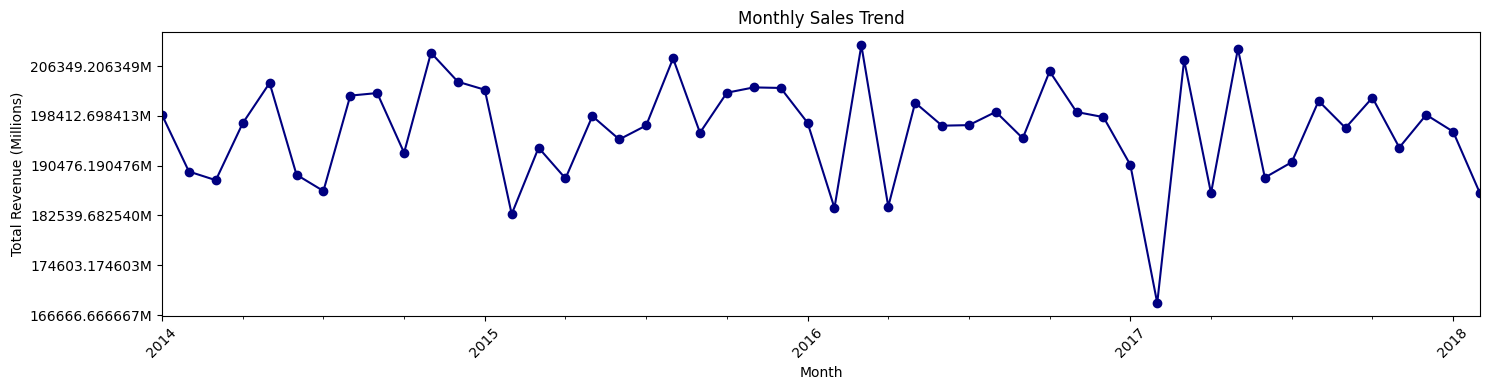

In [45]:
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize = (15,4))

monthly_sales.plot(marker = 'o',color='navy')

from matplotlib.ticker import FuncFormatter 
formatter = FuncFormatter(lambda x, pos: f'{x/126:1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()


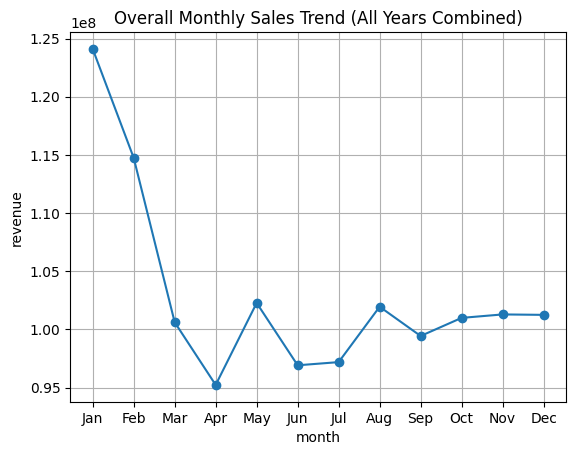

In [46]:
# Ensure date column is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month
df['month'] = df['order_date'].dt.month

# Aggregate sales across all years (you can use sum or mean)
monthly_sales = df.groupby('month')['revenue'].sum()

# Optional: map month numbers to names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_sales.index = month_names

# Plot
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Overall Monthly Sales Trend (All Years Combined)')
plt.xlabel('month')
plt.ylabel('revenue')
plt.grid()

plt.show()

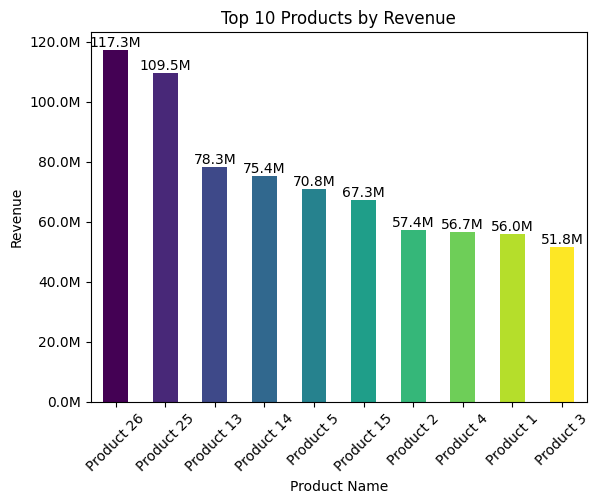

In [68]:
# Group by product and sum revenue
top_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# Colors (gradient)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_products)))

# Plot bar chart
plt.figure()
ax = top_products.plot(kind='bar')
ax = top_products.plot(kind='bar', color=colors)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

# Labels
for i, value in enumerate(top_products.values):
    ax.text(i, value, f'{value/1_000_000:.1f}M', ha='center', va='bottom')
ax.yaxis.set_major_formatter(
      mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
    
plt.show()

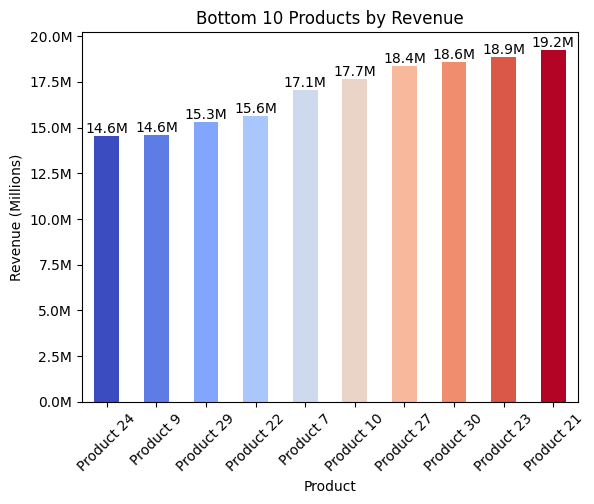

In [70]:
# Bottom 10 products by revenue
bottom_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

# Gradient colors
colors = plt.cm.coolwarm(np.linspace(0, 1, len(bottom_products)))

# Plot
plt.figure()
ax = bottom_products.plot(kind='bar', color=colors)

plt.title('Bottom 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Millions)')
plt.xticks(rotation=45)

# Labels in Millions
for i, value in enumerate(bottom_products.values):
    ax.text(i, value, f'{value/1_000_000:.1f}M', ha='center', va='bottom')

# Clean Y-axis in Millions
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)

plt.show()

<Figure size 300x300 with 0 Axes>

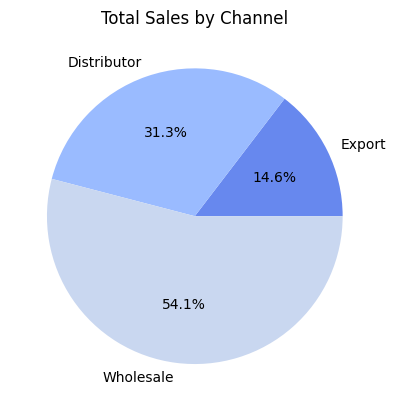

In [90]:
# Group by channel and sum revenue
channel_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(3,3))

# Plot pie chart
plt.figure()

plt.pie(
    channel_sales,
    labels=channel_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by Channel')

plt.show()

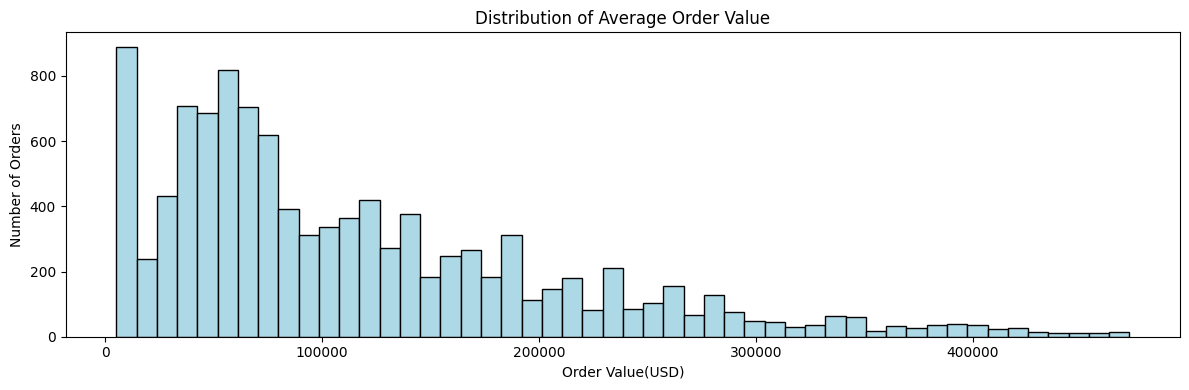

In [94]:
 #Average order value (AOV) Distribution 
aov = df.groupby('order_number')['revenue'].sum()
plt.figure(figsize = (12,4))

plt.hist(
    aov,
    bins=50,
    color='lightblue',
    edgecolor='black'

)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value(USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

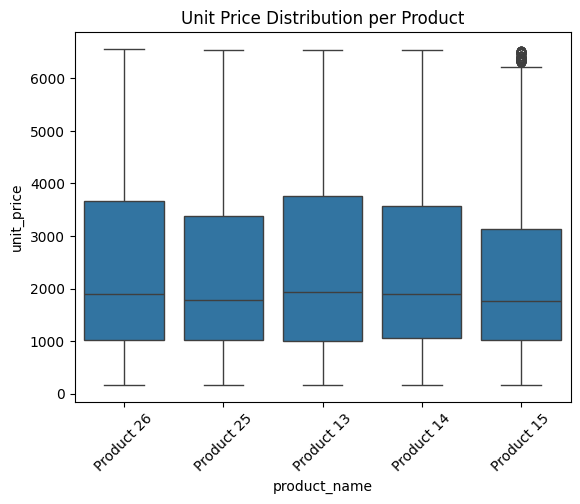

In [107]:
#Unit price distribution per product 
top_products = df['product_name'].value_counts().head(5).index

plt.figure()
sns.boxplot(
    data=df[df['product_name'].isin(top_products)],
    x='product_name',
    y='unit_price'
)

plt.xticks(rotation=45)
plt.title('Unit Price Distribution per Product')

plt.show()

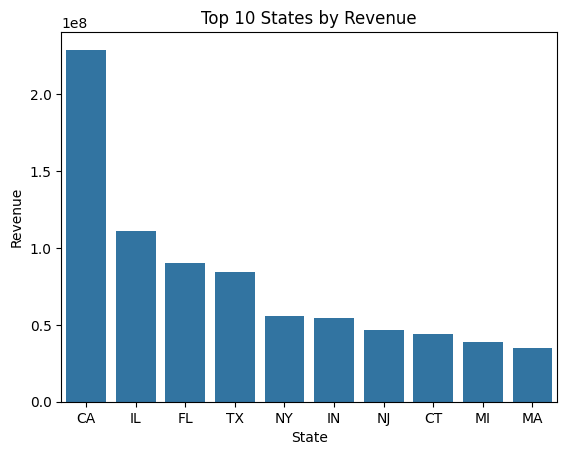

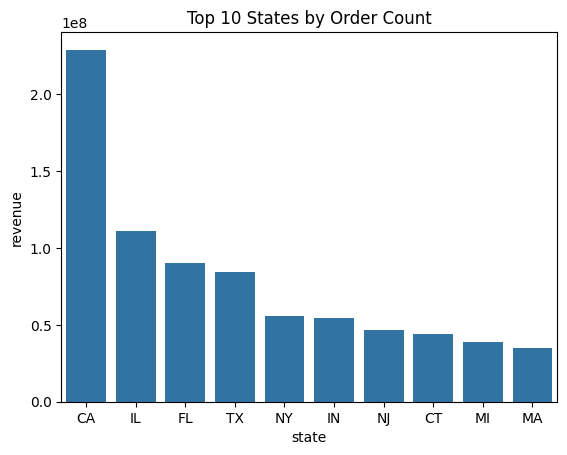

In [110]:
#Top 10 States by Revenue & Order Count
# Aggregate
state_data = df.groupby('state').agg({
    'revenue': 'sum',
    'order_quantity': 'count'
}).sort_values(by='revenue', ascending=False).head(10)

# Reset index for seaborn
state_data = state_data.reset_index()

# Plot
plt.figure()
sns.barplot(data=state_data, x='state', y='revenue')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()
# Top 10 States by Order Count
plt.figure()
sns.barplot(data=state_data, x='state', y='revenue')

plt.title('Top 10 States by Order Count')
plt.show()

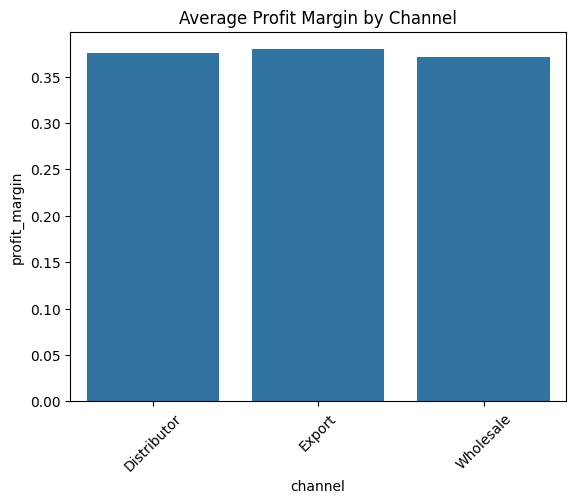

In [112]:
## Average Profit Margin by Channel
# Create profit margin column
df['profit_margin'] = df['profit'] / df['revenue']

channel_margin = df.groupby('channel')['profit_margin'].mean().reset_index()

plt.figure()
sns.barplot(data=channel_margin, x='channel', y='profit_margin')

plt.title('Average Profit Margin by Channel')
plt.xticks(rotation=45)

plt.show()

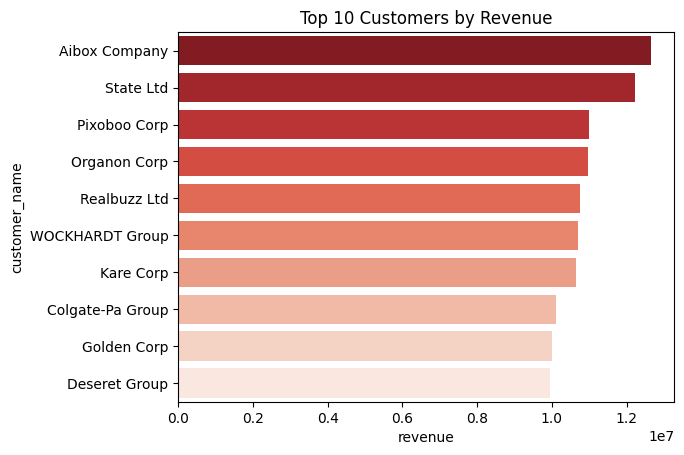

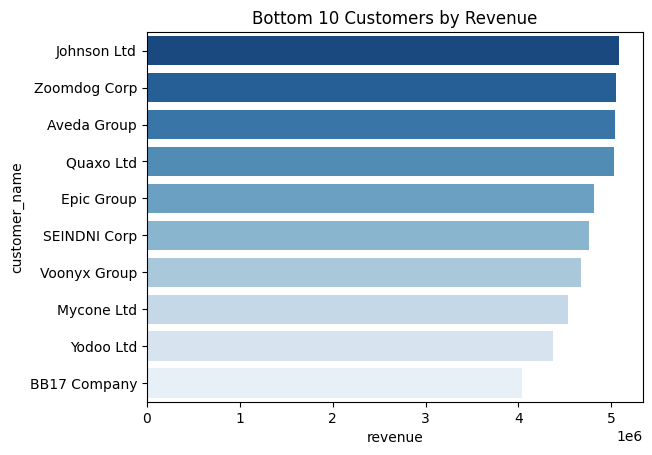

In [125]:
# Aggregate
customer_sales = (
    df.groupby('customer_name')['revenue']
    .sum()
    .sort_values(ascending=False)
)

top10 = customer_sales.head(10).reset_index()
bottom10 = customer_sales.tail(10).reset_index()

# 🔴 Top 10 → Red gradient (dark to light)
red_colors = sns.color_palette("Reds_r", n_colors=10)

plt.figure()
sns.barplot(
    data=top10,
    x='revenue',
    y='customer_name',
    hue='customer_name',
    palette=red_colors,
    legend=False
)
plt.title('Top 10 Customers by Revenue')
plt.show()


# 🔵 Bottom 10 → Blue gradient (dark to light)
blue_colors = sns.color_palette("Blues_r", n_colors=10)

plt.figure()
sns.barplot(
    data=bottom10,
    x='revenue',
    y='customer_name',
    hue='customer_name',   # 👈 important
    palette=blue_colors,
    legend=False
)
plt.title('Bottom 10 Customers by Revenue')
plt.show()

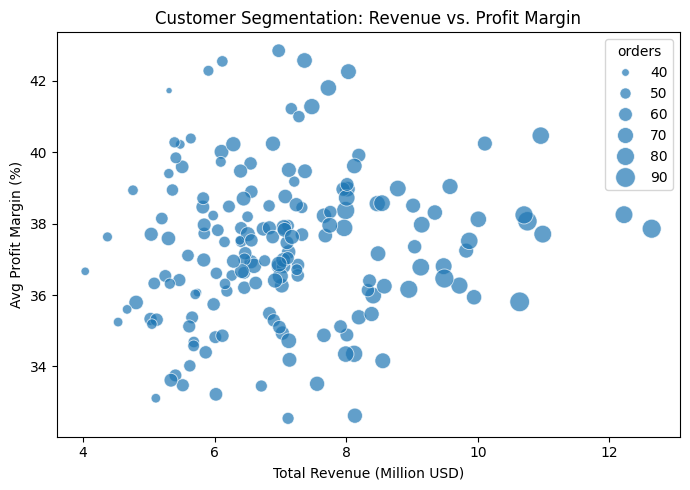

In [128]:
# Aggregate metrics per customer
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_per%', 'mean'),
    orders=('order_number', 'nunique')
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart with revenue in millions
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',        # <-- use revenue in millions
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')  # <-- updated label
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()

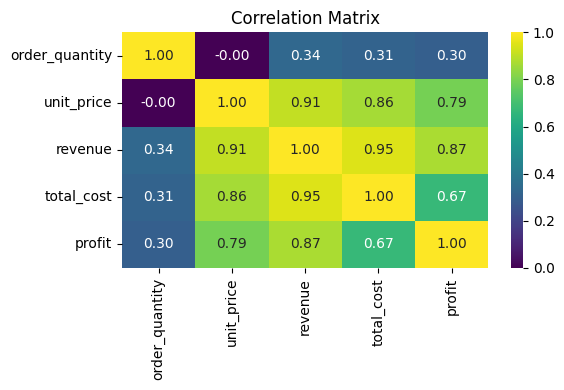

In [130]:
# List numeric columns to include in the correlation calculation
num_cols = ['order_quantity', 'unit_price', 'revenue', 'total_cost', 'profit']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot the heatmap with annotations and a viridis colormap
sns.heatmap(
    corr,           # Data: correlation matrix
    annot=True,     # Display the correlation coefficients on the heatmap
    fmt=".2f",      # Format numbers to two decimal places
    cmap='viridis'  # Color palette for the heatmap
)

# Add title for context
plt.title('Correlation Matrix')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the heatmap
plt.show()

In [131]:
df.to_csv('cleaned_data.csv', index=False)